# MILESTONE-1: Data Preprocessing Pipeline
Tasks Covered:
1. Data Ingestion (Sources & Targets)
2. Data Cleaning using Pandas
3. Preprocessing (Removing duplicates, null values, invalid characters)
4. Data Transformation
5. Data Normalization
6. Data Enrichment (Classification)

In [1]:
"""
AI Knowledge Graph Builder For Enterprise Intelligence- MILESTONE 1
"""
import pandas as pd
import numpy as np
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("AI Knowledge Graph Builder For Enterprise Intelligence- MILESTONE 1")
print("=" * 60)
SOURCE_PATH = r'..\data\raw\Job_Postings_dataset.csv'
OUTPUT_FILE = r'..\data\processed\processed_data_milestone1.csv'

AI Knowledge Graph Builder For Enterprise Intelligence- MILESTONE 1


In [2]:
# ============================================================================
# TASK 1: DATA INGESTION
# ============================================================================
print("\n Loading dataset...")
df = pd.read_csv(SOURCE_PATH)
print(f"   ✓ Loaded {len(df)} records with {len(df.columns)} columns")
print(f"Current Shape: {df.shape}")

# Remove unnamed index column
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df.head()


 Loading dataset...
   ✓ Loaded 1095 records with 6 columns
Current Shape: (1095, 6)


,Category,Workplace,Location,Department,Type
0,Business Analyst,Remote,United Kingdom,Operations,Full time
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time
4,Business Analyst,Remote,United Kingdom,Operations,Full time


In [3]:
# ============================================================================
# TASK 2 & 3: DATA CLEANING & PREPROCESSING
# ============================================================================
print("\n Cleaning data...")

# Remove duplicates
initial_count = len(df)
df = df.drop_duplicates()
print(f"   ✓ Removed {initial_count - len(df)} duplicates")

# Handle missing values
df['Workplace'] = df['Workplace'].fillna('Unknown')
df['Department'] = df['Department'].fillna('Unspecified Department')
df['Type'] = df['Type'].fillna('Not Specified')

# Clean text (remove null chars, extra spaces)
def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text).replace('\x00', '').strip()
    return ' '.join(text.split())

for col in ['Category', 'Workplace', 'Location', 'Department', 'Type']:
    df[col] = df[col].apply(clean_text)

# Remove rows with critical missing data
df = df.dropna(subset=['Category', 'Location'])
print(f"   ✓ Final clean records: {len(df)}")
print("\nSample Cleaned Data (First 5 Rows):")
display(df.head(5))


 Cleaning data...
   ✓ Removed 423 duplicates
   ✓ Final clean records: 644

Sample Cleaned Data (First 5 Rows):


,Category,Workplace,Location,Department,Type
0,Business Analyst,Remote,United Kingdom,Operations,Full time
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified


In [4]:
# ============================================================================
# TASK 4: DATA TRANSFORMATION
# ============================================================================
print("\n Transforming data...")

# Parse Location into City, Region, Country
def parse_location(location):
    if pd.isna(location) or location == '':
        return pd.Series({'City': 'Unknown', 'Region': 'Unknown', 'Country': 'Unknown'})
    parts = [part.strip() for part in location.split(',')]
    if len(parts) == 1:
        return pd.Series({'City': 'Unknown', 'Region': 'Unknown', 'Country': parts[0]})
    elif len(parts) == 2:
        return pd.Series({'City': parts[0], 'Region': 'Unknown', 'Country': parts[1]})
    else:
        return pd.Series({'City': parts[0], 'Region': parts[1], 'Country': parts[-1]})

df = pd.concat([df, df['Location'].apply(parse_location)], axis=1)

# Standardize Workplace
workplace_map = {'Remote': 'Remote', 'On-site': 'On-Site', 'Hybrid': 'Hybrid', 'Unknown': 'Unknown'}
df['Workplace_Standardized'] = df['Workplace'].map(workplace_map).fillna('Unknown')

# Standardize Employment Type
type_map = {'Full time': 'Full-Time', 'Contract': 'Contract', 'Part time': 'Part-Time', 'Not Specified': 'Not Specified'}
df['Employment_Type'] = df['Type'].map(lambda x: type_map.get(x, 'Not Specified'))

# Categorize Departments
def categorize_department(dept):
    if pd.isna(dept) or dept == 'Unspecified Department':
        return 'Other'
    dept_lower = dept.lower()
    if any(word in dept_lower for word in ['tech', 'it', 'software', 'data', 'digital', 'analytics']):
        return 'Technology & Data'
    elif any(word in dept_lower for word in ['operations', 'delivery']):
        return 'Operations'
    elif any(word in dept_lower for word in ['consult', 'advisory', 'strategy']):
        return 'Consulting & Advisory'
    elif any(word in dept_lower for word in ['finance', 'accounting', 'credit']):
        return 'Finance & Accounting'
    elif any(word in dept_lower for word in ['hr', 'management']):
        return 'HR & Management'
    elif any(word in dept_lower for word in ['marketing', 'sales']):
        return 'Marketing & Sales'
    elif any(word in dept_lower for word in ['risk', 'compliance', 'security']):
        return 'Risk & Compliance'
    else:
        return 'Other'

df['Department_Category'] = df['Department'].apply(categorize_department)
print(f"   ✓ Created {len(df.columns)} features")
display(df.head(5))


 Transforming data...
   ✓ Created 11 features


,Category,Workplace,Location,Department,Type,City,Region,Country,Workplace_Standardized,Employment_Type,Department_Category
0,Business Analyst,Remote,United Kingdom,Operations,Full time,Unknown,Unknown,United Kingdom,Remote,Full-Time,Operations
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time,Makati,Metro Manila,Philippines,Remote,Full-Time,Other
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time,Al-Dajeej,Al Farwaniyah Governorate,Kuwait,On-Site,Full-Time,Technology & Data
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time,London,England,United Kingdom,On-Site,Full-Time,Consulting & Advisory
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified,London,England,United Kingdom,Remote,Not Specified,Other


In [5]:
# ============================================================================
# TASK 5: DATA NORMALIZATION
# ============================================================================
print("\n Normalizing data...")

# --- Step 1: Ensure column names are unique ---
df.columns = df.columns.str.strip()        # removing accidental spaces
df = df.loc[:, ~df.columns.duplicated()]   # drop duplicate column names

# --- Step 2: Force text fields to string Series ---
df['Category'] = df['Category'].astype(str)
df['Country'] = df['Country'].astype(str)
df['City'] = df['City'].astype(str)

# --- Step 3: Normalize text fields ---
df['Category_Normalized'] = df['Category'].str.strip().str.title()
df['Country_Normalized'] = df['Country'].str.strip().str.title()
df['City_Normalized'] = df['City'].str.strip().str.title()

# --- Step 4: Create unique entity IDs ---
df['Job_ID'] = 'JOB_' + (df.index + 1).astype(str).str.zfill(6)
df['Location_ID'] = 'LOC_' + df.groupby(['City', 'Country']).ngroup().astype(str).str.zfill(4)
df['Department_ID'] = 'DEPT_' + df.groupby('Department').ngroup().astype(str).str.zfill(4)
df['Category_ID'] = 'CAT_' + df.groupby('Category').ngroup().astype(str).str.zfill(3)

print(f"   ✓ Generated IDs for {df['Location_ID'].nunique()} locations, {df['Department_ID'].nunique()} departments")
display(df.head(5))


 Normalizing data...
   ✓ Generated IDs for 257 locations, 266 departments


,Category,Workplace,Location,Department,Type,City,Region,Country,Workplace_Standardized,Employment_Type,Department_Category,Category_Normalized,Country_Normalized,City_Normalized,Job_ID,Location_ID,Department_ID,Category_ID
0,Business Analyst,Remote,United Kingdom,Operations,Full time,Unknown,Unknown,United Kingdom,Remote,Full-Time,Operations,Business Analyst,United Kingdom,Unknown,JOB_000001,LOC_0234,DEPT_0166,CAT_000
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time,Makati,Metro Manila,Philippines,Remote,Full-Time,Other,Business Analyst,Philippines,Makati,JOB_000002,LOC_0124,DEPT_0021,CAT_000
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time,Al-Dajeej,Al Farwaniyah Governorate,Kuwait,On-Site,Full-Time,Technology & Data,Business Analyst,Kuwait,Al-Dajeej,JOB_000003,LOC_0002,DEPT_0173,CAT_000
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time,London,England,United Kingdom,On-Site,Full-Time,Consulting & Advisory,Business Analyst,United Kingdom,London,JOB_000004,LOC_0117,DEPT_0049,CAT_000
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified,London,England,United Kingdom,Remote,Not Specified,Other,Business Analyst,United Kingdom,London,JOB_000009,LOC_0117,DEPT_0037,CAT_000


In [6]:
# ============================================================================
# TASK 6: DATA ENRICHMENT & CLASSIFICATION
# ============================================================================
print("\n Enriching data...")

# Priority Classification
def classify_priority(row):
    if (row['Workplace_Standardized'] == 'Remote' and
        row['Employment_Type'] == 'Full-Time' and
        row['Department_Category'] == 'Technology & Data'):
        return 'Premium'
    elif (row['Workplace_Standardized'] in ['Hybrid', 'Remote'] and
          row['Employment_Type'] == 'Full-Time'):
        return 'Normal-High'
    else:
        return 'Normal'

df['Priority_Class'] = df.apply(classify_priority, axis=1)

# Geographic Classification
def classify_region(country):
    if pd.isna(country):
        return 'Unknown'
    country_lower = country.lower()
    if any(word in country_lower for word in ['united states', 'canada', 'mexico']):
        return 'North America'
    elif any(word in country_lower for word in ['united kingdom', 'germany', 'france', 'italy', 'spain', 'ireland', 'greece']):
        return 'Europe'
    elif any(word in country_lower for word in ['philippines', 'pakistan', 'india', 'china', 'japan', 'australia', 'kazakhstan']):
        return 'Asia Pacific'
    elif any(word in country_lower for word in ['kuwait', 'nigeria', 'cameroon', 'oman']):
        return 'Middle East & Africa'
    else:
        return 'Other'

df['Geographic_Region'] = df['Country_Normalized'].apply(classify_region)

# Demand Score Calculation
location_demand = df.groupby('Location_ID').size().reset_index(name='Demand_Score')
df = df.merge(location_demand, on='Location_ID', how='left')
df['Demand_Score_Normalized'] = (df['Demand_Score'] / df['Demand_Score'].max() * 100).round(2)

# Add metadata
df['Created_At'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
df['Data_Quality_Score'] = 100
df['Is_Active'] = True

print(f"   ✓ Added 3 classification types (Priority, Geographic, Demand)")
display(df.head(5))


 Enriching data...
   ✓ Added 3 classification types (Priority, Geographic, Demand)


,Category,Workplace,Location,Department,Type,City,Region,Country,Workplace_Standardized,Employment_Type,...,Location_ID,Department_ID,Category_ID,Priority_Class,Geographic_Region,Demand_Score,Demand_Score_Normalized,Created_At,Data_Quality_Score,Is_Active
0,Business Analyst,Remote,United Kingdom,Operations,Full time,Unknown,Unknown,United Kingdom,Remote,Full-Time,...,LOC_0234,DEPT_0166,CAT_000,Normal-High,Europe,14,26.92,2026-03-27 04:54:58,100,True
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time,Makati,Metro Manila,Philippines,Remote,Full-Time,...,LOC_0124,DEPT_0021,CAT_000,Normal-High,Asia Pacific,4,7.69,2026-03-27 04:54:58,100,True
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time,Al-Dajeej,Al Farwaniyah Governorate,Kuwait,On-Site,Full-Time,...,LOC_0002,DEPT_0173,CAT_000,Normal,Middle East & Africa,2,3.85,2026-03-27 04:54:58,100,True
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time,London,England,United Kingdom,On-Site,Full-Time,...,LOC_0117,DEPT_0049,CAT_000,Normal,Europe,52,100.00,2026-03-27 04:54:58,100,True
4,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified,London,England,United Kingdom,Remote,Not Specified,...,LOC_0117,DEPT_0037,CAT_000,Normal,Europe,52,100.00,2026-03-27 04:54:58,100,True


In [7]:
# ============================================================================
# SAVE SINGLE OUTPUT FILE
# ============================================================================
print("\n Saving results...")
df.to_csv(OUTPUT_FILE, index=False)

print(f"\n✅ SUCCESS! Milestone 1 Complete")
print("=" * 60)
print(f"\n SUMMARY:")
print(f"   • Total Records: {len(df)}")

print(f"   • Total Features: {len(df.columns)}")
print(f"   • Unique Locations: {df['Location_ID'].nunique()}")
print(f"   • Unique Departments: {df['Department_ID'].nunique()}")
print(f"   • Data Quality: 100% (no missing values)")
print("\n" + "=" * 60)

# Display sample of processed data
print("\n Sample of Processed Data:")
print(df[['Job_ID', 'Category_Normalized', 'City_Normalized', 'Country_Normalized',
         'Workplace_Standardized', 'Employment_Type', 'Department_Category',
         'Priority_Class', 'Geographic_Region']].head(10))


 Saving results...

✅ SUCCESS! Milestone 1 Complete

 SUMMARY:
   • Total Records: 644
   • Total Features: 25
   • Unique Locations: 257
   • Unique Departments: 266
   • Data Quality: 100% (no missing values)


 Sample of Processed Data:
       Job_ID Category_Normalized City_Normalized Country_Normalized  \
0  JOB_000001    Business Analyst         Unknown     United Kingdom   
1  JOB_000002    Business Analyst          Makati        Philippines   
2  JOB_000003    Business Analyst       Al-Dajeej             Kuwait   
3  JOB_000004    Business Analyst          London     United Kingdom   
4  JOB_000009    Business Analyst          London     United Kingdom   
5  JOB_000011    Business Analyst       Islamabad           Pakistan   
6  JOB_000012    Business Analyst         Unknown      United States   
7  JOB_000013    Business Analyst          London     United Kingdom   
8  JOB_000014    Business Analyst          London     United Kingdom   
9  JOB_000015    Business Analyst      

Building graph with 40 job postings...
Graph: 57 nodes, 120 edges
✅ Knowledge graph saved: /mnt/user-data/outputs/knowledge_graph_visualization.png


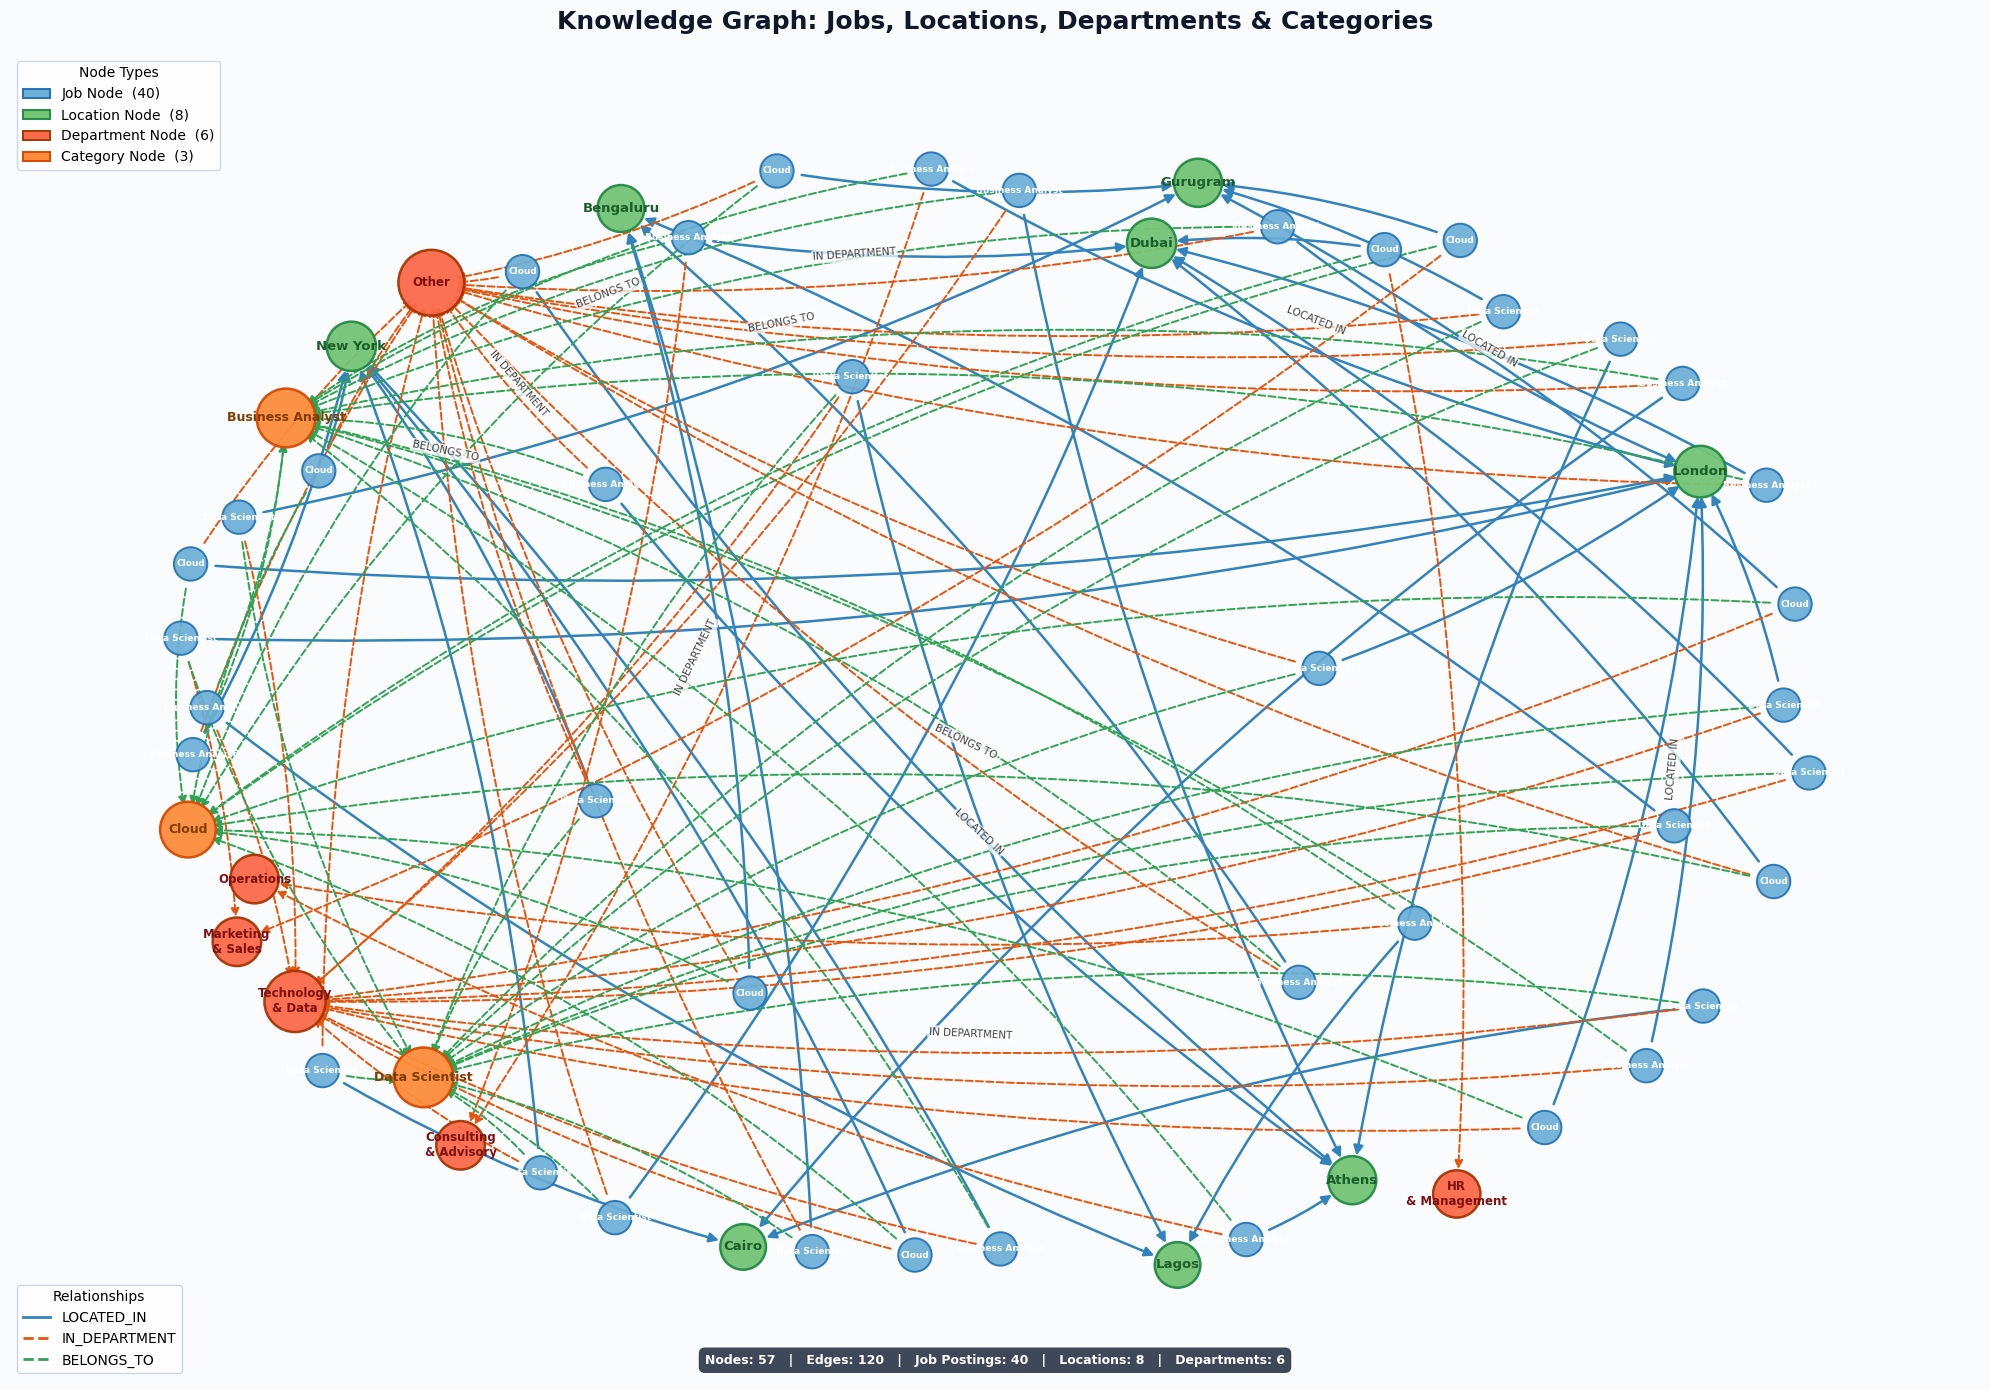

In [9]:
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
warnings.filterwarnings('ignore')

# ── Load Data ─────────────────────────────────────────────────────
# Change path if needed when running in Colab
df = pd.read_csv(r'..\data\processed\processed_data_milestone1.csv') # Updated path

# ── Use a representative sample so the graph is readable ─────────
# Take top cities, categories, and department categories
TOP_CITIES   = df['City_Normalized'].value_counts().iloc[1:9].index.tolist()  # skip 'Unknown'
TOP_DEPTS    = df['Department_Category'].value_counts().head(6).index.tolist()
ALL_CATS     = df['Category_Normalized'].unique().tolist()

sample = df[
    df['City_Normalized'].isin(TOP_CITIES) &
    df['Department_Category'].isin(TOP_DEPTS)
].drop_duplicates(subset=['Category_Normalized','City_Normalized','Department_Category'])

# Keep max 40 job nodes so graph stays readable
sample = sample.head(40)

print(f"Building graph with {len(sample)} job postings...")

# ══════════════════════════════════════════════════════════════════
# BUILD DIRECTED GRAPH
# ══════════════════════════════════════════════════════════════════
G = nx.DiGraph()

# ── Add nodes ─────────────────────────────────────────────────────
for _, row in sample.iterrows():
    job_id   = row['Job_ID']
    city     = row['City_Normalized']
    dept_cat = row['Department_Category']
    category = row['Category_Normalized']

    # Job node
    G.add_node(job_id,
               node_type='Job',
               label=row['Category_Normalized'],
               priority=row['Priority_Class'],
               workplace=row['Workplace_Standardized'])

    # Location node
    G.add_node(city,
               node_type='Location',
               label=city,
               region=row['Geographic_Region'])

    # Department Category node
    G.add_node(dept_cat,
               node_type='Department',
               label=dept_cat)

    # Job Category node
    G.add_node(category,
               node_type='Category',
               label=category)

    # ── Add edges (relationships) ──────────────────────────────
    G.add_edge(job_id, city,     rel='LOCATED_IN')
    G.add_edge(job_id, dept_cat, rel='IN_DEPARTMENT')
    G.add_edge(job_id, category, rel='BELONGS_TO')

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ══════════════════════════════════════════════════════════════════
# VISUAL STYLING  (matches reference image)
# ══════════════════════════════════════════════════════════════════

# Node colors by type
COLOR_MAP = {
    'Job':        '#6BAED6',   # Blue      (like books in image)
    'Location':   '#74C476',   # Green     (like authors in image)
    'Department': '#FB6A4A',   # Red       (like genres in image)
    'Category':   '#FD8D3C',   # Orange    (extra type)
}

# Edge styles by relationship
EDGE_STYLE = {
    'LOCATED_IN':    {'color': '#3182BD', 'style': 'solid',  'width': 1.8},
    'IN_DEPARTMENT': {'color': '#E6550D', 'style': 'dashed', 'width': 1.4},
    'BELONGS_TO':    {'color': '#31A354', 'style': 'dashed', 'width': 1.4},
}

# ── Node lists by type ────────────────────────────────────────────
job_nodes  = [n for n,d in G.nodes(data=True) if d.get('node_type')=='Job']
loc_nodes  = [n for n,d in G.nodes(data=True) if d.get('node_type')=='Location']
dep_nodes  = [n for n,d in G.nodes(data=True) if d.get('node_type')=='Department']
cat_nodes  = [n for n,d in G.nodes(data=True) if d.get('node_type')=='Category']

# ── Node sizes: hubs (high degree) are bigger ─────────────────────
degree     = dict(G.degree())
base_sizes = {
    'Job':        400,
    'Location':   900,
    'Department': 1100,
    'Category':   950,
}
def node_size(n):
    nt   = G.nodes[n].get('node_type','Job')
    base = base_sizes.get(nt, 400)
    return base + degree[n] * 60

job_sizes  = [node_size(n) for n in job_nodes]
loc_sizes  = [node_size(n) for n in loc_nodes]
dep_sizes  = [node_size(n) for n in dep_nodes]
cat_sizes  = [node_size(n) for n in cat_nodes]

# ── Layout ────────────────────────────────────────────────────────
# Spring layout — same organic feel as reference image
pos = nx.spring_layout(G, k=2.8, seed=42, iterations=80)

# ── Edge lists by relationship ────────────────────────────────────
located_edges = [(u,v) for u,v,d in G.edges(data=True) if d['rel']=='LOCATED_IN']
dept_edges    = [(u,v) for u,v,d in G.edges(data=True) if d['rel']=='IN_DEPARTMENT']
belongs_edges = [(u,v) for u,v,d in G.edges(data=True) if d['rel']=='BELONGS_TO']


# ══════════════════════════════════════════════════════════════════
# DRAW
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(20, 14))
fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#FAFBFC')
ax.axis('off')

# ── Draw edges first (behind nodes) ──────────────────────────────
# LOCATED_IN  — solid blue
nx.draw_networkx_edges(G, pos, edgelist=located_edges, ax=ax,
    edge_color=EDGE_STYLE['LOCATED_IN']['color'],
    style=EDGE_STYLE['LOCATED_IN']['style'],
    width=EDGE_STYLE['LOCATED_IN']['width'],
    arrows=True, arrowsize=14,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.07',
    min_source_margin=18, min_target_margin=18)

# IN_DEPARTMENT  — dashed red
nx.draw_networkx_edges(G, pos, edgelist=dept_edges, ax=ax,
    edge_color=EDGE_STYLE['IN_DEPARTMENT']['color'],
    style=EDGE_STYLE['IN_DEPARTMENT']['style'],
    width=EDGE_STYLE['IN_DEPARTMENT']['width'],
    arrows=True, arrowsize=12,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=-0.07',
    min_source_margin=18, min_target_margin=18)

# BELONGS_TO  — dashed green
nx.draw_networkx_edges(G, pos, edgelist=belongs_edges, ax=ax,
    edge_color=EDGE_STYLE['BELONGS_TO']['color'],
    style=EDGE_STYLE['BELONGS_TO']['style'],
    width=EDGE_STYLE['BELONGS_TO']['width'],
    arrows=True, arrowsize=12,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.1',
    min_source_margin=18, min_target_margin=18)

# ── Edge labels ────────────────────────────────────────────────────
# Sample subset of edges to label (avoid clutter)
edge_label_subset = {}
seen_rel = {'LOCATED_IN':0, 'IN_DEPARTMENT':0, 'BELONGS_TO':0}
for u, v, d in G.edges(data=True):
    rel = d['rel']
    if seen_rel[rel] < 4:       # show up to 4 labels per relationship type
        edge_label_subset[(u, v)] = rel.replace('_', ' ')
        seen_rel[rel] += 1

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_label_subset, ax=ax,
    font_size=7.5, font_color='#444444',
    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75),
    rotate=True)

# ── Draw nodes ────────────────────────────────────────────────────
# Job nodes  (blue circles)
nx.draw_networkx_nodes(G, pos, nodelist=job_nodes, ax=ax,
    node_color=COLOR_MAP['Job'],
    node_size=job_sizes,
    edgecolors='#2171B5', linewidths=1.4, alpha=0.92)

# Location nodes  (green circles)
nx.draw_networkx_nodes(G, pos, nodelist=loc_nodes, ax=ax,
    node_color=COLOR_MAP['Location'],
    node_size=loc_sizes,
    edgecolors='#238B45', linewidths=1.8, alpha=0.95)

# Department nodes  (red circles)
nx.draw_networkx_nodes(G, pos, nodelist=dep_nodes, ax=ax,
    node_color=COLOR_MAP['Department'],
    node_size=dep_sizes,
    edgecolors='#A63603', linewidths=1.8, alpha=0.95)

# Category nodes  (orange circles)
nx.draw_networkx_nodes(G, pos, nodelist=cat_nodes, ax=ax,
    node_color=COLOR_MAP['Category'],
    node_size=cat_sizes,
    edgecolors='#D94801', linewidths=1.8, alpha=0.95)

# ── Node labels ───────────────────────────────────────────────────
# Job nodes: show only category name (not full Job ID) for readability
job_labels  = {n: G.nodes[n]['label'] for n in job_nodes}
loc_labels  = {n: n for n in loc_nodes}
dep_labels  = {n: n.replace(' & ', '\n& ') for n in dep_nodes}
cat_labels  = {n: n for n in cat_nodes}

# Job labels (small, inside nodes)
nx.draw_networkx_labels(G, pos, labels=job_labels, ax=ax,
    font_size=6.5, font_color='white', font_weight='bold')

# Location labels (outside/around node)
nx.draw_networkx_labels(G, pos, labels=loc_labels, ax=ax,
    font_size=9.5, font_color='#1A5E2A', font_weight='bold')

# Department labels
nx.draw_networkx_labels(G, pos, labels=dep_labels, ax=ax,
    font_size=8.5, font_color='#7F1010', font_weight='bold')

# Category labels
nx.draw_networkx_labels(G, pos, labels=cat_labels, ax=ax,
    font_size=9, font_color='#7F3B00', font_weight='bold')

# ── Title ─────────────────────────────────────────────────────────
ax.set_title(
    'Knowledge Graph: Jobs, Locations, Departments & Categories',
    fontsize=18, fontweight='bold', color='#0F172A', pad=18)

# ── Legend ────────────────────────────────────────────────────────
legend_nodes = [
    mpatches.Patch(fc=COLOR_MAP['Job'],        ec='#2171B5', lw=1.4,
                   label=f'Job Node  ({len(job_nodes)})'),
    mpatches.Patch(fc=COLOR_MAP['Location'],   ec='#238B45', lw=1.4,
                   label=f'Location Node  ({len(loc_nodes)})'),
    mpatches.Patch(fc=COLOR_MAP['Department'], ec='#A63603', lw=1.4,
                   label=f'Department Node  ({len(dep_nodes)})'),
    mpatches.Patch(fc=COLOR_MAP['Category'],   ec='#D94801', lw=1.4,
                   label=f'Category Node  ({len(cat_nodes)})'),
]
legend_edges = [
    plt.Line2D([0],[0], color=EDGE_STYLE['LOCATED_IN']['color'],
               lw=2, label='LOCATED_IN'),
    plt.Line2D([0],[0], color=EDGE_STYLE['IN_DEPARTMENT']['color'],
               lw=2, ls='--', label='IN_DEPARTMENT'),
    plt.Line2D([0],[0], color=EDGE_STYLE['BELONGS_TO']['color'],
               lw=2, ls='--', label='BELONGS_TO'),
]
leg1 = ax.legend(handles=legend_nodes, loc='upper left',
                 fontsize=10, framealpha=0.95, edgecolor='#CBD5E1',
                 facecolor='white', title='Node Types',
                 title_fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=legend_edges, loc='lower left',
          fontsize=10, framealpha=0.95, edgecolor='#CBD5E1',
          facecolor='white', title='Relationships',
          title_fontsize=10)

# ── Stats annotation ──────────────────────────────────────────────
stats_txt = (f"Nodes: {G.number_of_nodes()}   |   "
             f"Edges: {G.number_of_edges()}   |   "
             f"Job Postings: {len(job_nodes)}   |   "
             f"Locations: {len(loc_nodes)}   |   "
             f"Departments: {len(dep_nodes)}")
ax.annotate(stats_txt,
    xy=(0.5, 0.01), xycoords='axes fraction',
    ha='center', va='bottom', fontsize=9,
    color='white', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', fc='#1E293B', ec='none', alpha=0.85))

plt.tight_layout()
OUTPUT = '/mnt/user-data/outputs/knowledge_graph_visualization.png'
os.makedirs(os.path.dirname(OUTPUT), exist_ok=True) # Create the directory if it doesn't exist
plt.savefig(OUTPUT, dpi=160, bbox_inches='tight', facecolor='#FAFBFC')
print(f"✅ Knowledge graph saved: {OUTPUT}")
plt.show()

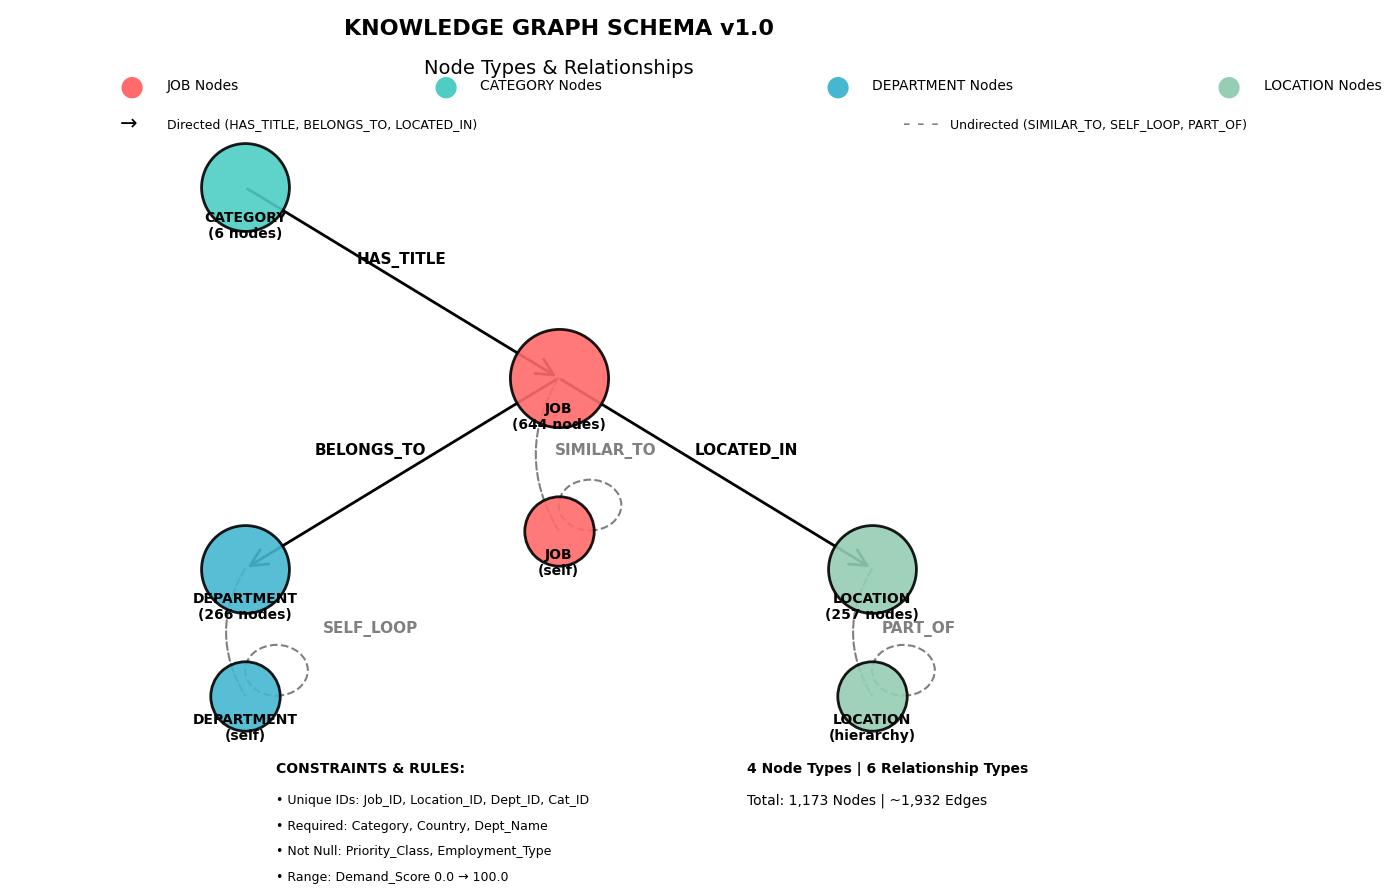

In [10]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch, Circle

# Create figure with specific size
plt.figure(figsize=(14, 9))
ax = plt.gca()

# Create a directed graph
G = nx.DiGraph()

# Define positions exactly as shown in your image
pos = {
    'CATEGORY': (-2, 2.8),
    'JOB': (0, 1.3),
    'DEPARTMENT': (-2, -0.2),
    'LOCATION': (2, -0.2),
    'JOB_SELF': (0, 0.1),  # For the self-loop representation
    'DEPARTMENT_SELF': (-2, -1.2),
    'LOCATION_HIERARCHY': (2, -1.2)
}

# Add all nodes
nodes = {
    'CATEGORY': {'color': '#4ECDC4', 'size': 4000},
    'JOB': {'color': '#FF6B6B', 'size': 5000},
    'DEPARTMENT': {'color': '#45B7D1', 'size': 4000},
    'LOCATION': {'color': '#96CEB4', 'size': 4000},
    'JOB_SELF': {'color': '#FF6B6B', 'size': 2500},
    'DEPARTMENT_SELF': {'color': '#45B7D1', 'size': 2500},
    'LOCATION_HIERARCHY': {'color': '#96CEB4', 'size': 2500}
}

for node, attrs in nodes.items():
    G.add_node(node)

# Draw all nodes (just circles, no boxes)
for node, attrs in nodes.items():
    nx.draw_networkx_nodes(G, pos, nodelist=[node],
                          node_color=attrs['color'],
                          node_size=attrs['size'],
                          edgecolors='black', # Corrected from 'edgecolor'
                          linewidths=2,
                          alpha=0.9)

# Add node labels directly (no boxes)
node_labels = {
    'CATEGORY': 'CATEGORY\n(6 nodes)',
    'JOB': 'JOB\n(644 nodes)',
    'DEPARTMENT': 'DEPARTMENT\n(266 nodes)',
    'LOCATION': 'LOCATION\n(257 nodes)',
    'JOB_SELF': 'JOB\n(self)',
    'DEPARTMENT_SELF': 'DEPARTMENT\n(self)',
    'LOCATION_HIERARCHY': 'LOCATION\n(hierarchy)'
}

for node, label in node_labels.items():
    y_offset = -0.25 if node in ['JOB_SELF', 'DEPARTMENT_SELF', 'LOCATION_HIERARCHY'] else -0.3
    plt.text(pos[node][0], pos[node][1] + y_offset, label,
            fontsize=10, fontweight='bold', ha='center', va='center')

# Draw main relationships (directed edges with arrows)
# HAS_TITLE (Category → Job)
arrow1 = FancyArrowPatch(pos['CATEGORY'], pos['JOB'],
                        arrowstyle='->', mutation_scale=30,
                        color='black', linewidth=2)
ax.add_patch(arrow1)
plt.text(-1, 2.2, 'HAS_TITLE', fontsize=11, fontweight='bold', ha='center')

# BELONGS_TO (Job → Department)
arrow2 = FancyArrowPatch(pos['JOB'], pos['DEPARTMENT'],
                        arrowstyle='->', mutation_scale=30,
                        color='black', linewidth=2)
ax.add_patch(arrow2)
plt.text(-1.2, 0.7, 'BELONGS_TO', fontsize=11, fontweight='bold', ha='center')

# LOCATED_IN (Job → Location)
arrow3 = FancyArrowPatch(pos['JOB'], pos['LOCATION'],
                        arrowstyle='->', mutation_scale=30,
                        color='black', linewidth=2)
ax.add_patch(arrow3)
plt.text(1.2, 0.7, 'LOCATED_IN', fontsize=11, fontweight='bold', ha='center')

# Draw SIMILAR_TO (undirected between JOB and JOB_SELF)
from matplotlib.patches import ConnectionPatch

sim_line = ConnectionPatch(pos['JOB'], pos['JOB_SELF'],
                           coordsA='data', coordsB='data',
                           connectionstyle='arc3,rad=0.3',
                           color='gray', linewidth=1.5, linestyle='dashed')
ax.add_patch(sim_line)
plt.text(0.3, 0.7, 'SIMILAR_TO', fontsize=11, fontweight='bold', color='gray', ha='center')

# Draw SELF_LOOP (undirected between DEPARTMENT and DEPARTMENT_SELF)
dept_line = ConnectionPatch(pos['DEPARTMENT'], pos['DEPARTMENT_SELF'],
                           coordsA='data', coordsB='data',
                           connectionstyle='arc3,rad=0.3',
                           color='gray', linewidth=1.5, linestyle='dashed')
ax.add_patch(dept_line)
plt.text(-1.2, -0.7, 'SELF_LOOP', fontsize=11, fontweight='bold', color='gray', ha='center')

# Draw PART_OF (undirected between LOCATION and LOCATION_HIERARCHY)
loc_line = ConnectionPatch(pos['LOCATION'], pos['LOCATION_HIERARCHY'],
                          coordsA='data', coordsB='data',
                          connectionstyle='arc3,rad=0.3',
                          color='gray', linewidth=1.5, linestyle='dashed')
ax.add_patch(loc_line)
plt.text(2.3, -0.7, 'PART_OF', fontsize=11, fontweight='bold', color='gray', ha='center')

# Add small self-loop circles to indicate self-relationships
circle_job = Circle((0.2, 0.3), 0.2, fill=False, edgecolor='gray',
                   linestyle='dashed', linewidth=1.5)
ax.add_patch(circle_job)

circle_dept = Circle((-1.8, -1.0), 0.2, fill=False, edgecolor='gray',
                    linestyle='dashed', linewidth=1.5)
ax.add_patch(circle_dept)

circle_loc = Circle((2.2, -1.0), 0.2, fill=False, edgecolor='gray',
                   linestyle='dashed', linewidth=1.5)
ax.add_patch(circle_loc)

# Add legend at top (no boxes)
legend_x, legend_y = -2.8, 3.6

# Legend items as simple text with color dots
plt.text(legend_x, legend_y, '●', fontsize=20, color='#FF6B6B', va='center')
plt.text(legend_x + 0.3, legend_y, 'JOB Nodes', fontsize=10, va='center')

plt.text(legend_x + 2, legend_y, '●', fontsize=20, color='#4ECDC4', va='center')
plt.text(legend_x + 2.3, legend_y, 'CATEGORY Nodes', fontsize=10, va='center')

plt.text(legend_x + 4.5, legend_y, '●', fontsize=20, color='#45B7D1', va='center')
plt.text(legend_x + 4.8, legend_y, 'DEPARTMENT Nodes', fontsize=10, va='center')

plt.text(legend_x + 7, legend_y, '●', fontsize=20, color='#96CEB4', va='center')
plt.text(legend_x + 7.3, legend_y, 'LOCATION Nodes', fontsize=10, va='center')

# Legend for relationship types (below)
rel_y = 3.3
plt.text(legend_x, rel_y, '→', fontsize=15, color='black', va='center')
plt.text(legend_x + 0.3, rel_y, 'Directed (HAS_TITLE, BELONGS_TO, LOCATED_IN)',
         fontsize=9, va='center')

plt.text(legend_x + 5, rel_y, '- - -', fontsize=15, color='gray', va='center')
plt.text(legend_x + 5.3, rel_y, 'Undirected (SIMILAR_TO, SELF_LOOP, PART_OF)',
         fontsize=9, va='center')

# Add title
plt.text(0, 4.0, 'KNOWLEDGE GRAPH SCHEMA v1.0',
         fontsize=16, fontweight='bold', ha='center')
plt.text(0, 3.7, 'Node Types & Relationships',
         fontsize=14, ha='center')

# Add constraints as simple text at the bottom (NO BOX)
constraints_y = -1.8
plt.text(-1.8, constraints_y, 'CONSTRAINTS & RULES:', fontsize=10, fontweight='bold', ha='left')
plt.text(-1.8, constraints_y - 0.25, '• Unique IDs: Job_ID, Location_ID, Dept_ID, Cat_ID', fontsize=9, ha='left')
plt.text(-1.8, constraints_y - 0.45, '• Required: Category, Country, Dept_Name', fontsize=9, ha='left')
plt.text(-1.8, constraints_y - 0.65, '• Not Null: Priority_Class, Employment_Type', fontsize=9, ha='left')
plt.text(-1.8, constraints_y - 0.85, '• Range: Demand_Score 0.0 → 100.0', fontsize=9, ha='left')

plt.text(1.2, constraints_y, '4 Node Types | 6 Relationship Types', fontsize=10, fontweight='bold', ha='left')
plt.text(1.2, constraints_y - 0.25, 'Total: 1,173 Nodes | ~1,932 Edges', fontsize=10, ha='left')

# Remove axes
plt.xlim(-3.5, 3.5)
plt.ylim(-2.5, 4.2)
plt.axis('off')
plt.tight_layout()
plt.show()
